# Week 4 — Supplier Risk Segmentation
## Supply Chain Intelligence Project

**Input:** `cleaned_supply_chain.csv` (from Week 1)  
**Output:** `supplier_risk_scores.csv`, `supplier_segments.csv`, `supplier_risk_model.pkl`

### Objectives
1. Build a supplier risk profile from order-level data
2. Engineer supplier-level KPIs (late rate, avg delay, cancel rate, revenue)
3. Score every supplier 0–100 on risk
4. K-Means clustering into 3 risk tiers (Low / Medium / High)
5. Visualise supplier risk landscape
6. Business recommendations per tier

> **Note:** The DataCo dataset does not have a dedicated supplier column.
> We use `Order Region` as a supplier proxy — each region represents
> a supply origin with its own reliability profile. This is a standard
> approach when supplier IDs are unavailable.

---
## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
import os
import pickle

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# ── Load clean data ────────────────────────────────────────────
df = pd.read_csv('../data/processed/cleaned_supply_chain.csv',
                 parse_dates=['Order Date', 'Ship Date'])

print(f'Dataset shape : {df.shape}')
print(f'Unique regions: {df["Order Region"].nunique()}')
print(f'Unique markets: {df["Market"].nunique()}')
print('Data loaded ✓')

Dataset shape : (180519, 49)
Unique regions: 23
Unique markets: 5
Data loaded ✓


---
## 2. Build Supplier (Region) Risk Profiles

In [2]:
# ── Aggregate order-level data to region level ─────────────────
supplier_df = df.groupby('Order Region').agg(
    Total_Orders      = ('Is_Late',               'count'),
    Late_Orders       = ('Is_Late',               'sum'),
    Late_Rate         = ('Is_Late',               'mean'),
    Avg_Delay_Days    = ('Delivery_Delay_Days',   'mean'),
    Max_Delay_Days    = ('Delivery_Delay_Days',   'max'),
    Cancel_Rate       = ('Is_Cancelled',          'mean'),
    Total_Revenue     = ('Revenue',               'sum'),
    Avg_Order_Value   = ('Revenue',               'mean'),
    Revenue_At_Risk   = ('Revenue_At_Risk',       'sum'),
    Avg_Profit        = ('Order Profit Per Order','mean'),
    Unique_Categories = ('Category Name',         'nunique'),
    Unique_Markets    = ('Market',                'nunique')
).reset_index()

# Round for readability
supplier_df = supplier_df.round(4)

print(f'Supplier profiles built: {len(supplier_df)} regions')
print()
display(supplier_df.sort_values('Late_Rate', ascending=False))

Supplier profiles built: 23 regions



,Order Region,Total_Orders,Late_Orders,Late_Rate,Avg_Delay_Days,Max_Delay_Days,Cancel_Rate,Total_Revenue,Avg_Order_Value,Revenue_At_Risk,Avg_Profit,Unique_Categories,Unique_Markets
2,Central Africa,1677,972,0.5796,0.6398,4,0.0197,3.272630e+05,195.1479,1.876883e+05,19.9447,24,1
13,South Asia,7731,4350,0.5627,0.5975,4,0.0171,1.553681e+06,200.9677,8.714717e+05,21.4337,42,1
5,East Africa,1852,1036,0.5594,0.5707,4,0.0216,3.762349e+05,203.1506,2.104439e+05,23.3087,24,1
22,Western Europe,27109,15140,0.5585,0.5974,4,0.0198,5.894381e+06,217.4326,3.292014e+06,23.0715,41,1
14,South of USA,4045,2256,0.5577,0.5800,4,0.0307,7.857839e+05,194.2606,4.360881e+05,21.7837,24,1
6,East of USA,6915,3849,0.5566,0.5848,4,0.0214,1.371112e+06,198.2808,7.540793e+05,22.5977,24,1
8,Eastern Europe,3920,2182,0.5566,0.5798,4,0.0156,7.742666e+05,197.5170,4.325138e+05,20.3360,24,1
15,Southeast Asia,9539,5297,0.5553,0.5582,4,0.0226,1.932496e+06,202.5889,1.073898e+06,22.1557,42,1
4,Central Asia,553,306,0.5533,0.6456,4,0.0090,1.098399e+05,198.6256,5.973370e+04,23.5900,20,1
20,West Asia,6009,3322,0.5528,0.5695,4,0.0193,1.174672e+06,195.4854,6.563773e+05,19.7729,24,1


In [3]:
# ── Revenue at risk percentage ─────────────────────────────────
supplier_df['Risk_Revenue_Pct'] = (
    supplier_df['Revenue_At_Risk'] / supplier_df['Total_Revenue'] * 100
).round(2)

# ── Order volume share ─────────────────────────────────────────
supplier_df['Order_Share_Pct'] = (
    supplier_df['Total_Orders'] / supplier_df['Total_Orders'].sum() * 100
).round(2)

print('Additional metrics computed ✓')
print(supplier_df[['Order Region', 'Late_Rate', 'Risk_Revenue_Pct', 'Order_Share_Pct']]
      .sort_values('Late_Rate', ascending=False).to_string(index=False))

Additional metrics computed ✓
   Order Region  Late_Rate  Risk_Revenue_Pct  Order_Share_Pct
 Central Africa     0.5796             57.35             0.93
     South Asia     0.5627             56.09             4.28
    East Africa     0.5594             55.93             1.03
 Western Europe     0.5585             55.85            15.02
 South of  USA      0.5577             55.50             2.24
    East of USA     0.5566             55.00             3.83
 Eastern Europe     0.5566             55.86             2.17
 Southeast Asia     0.5553             55.57             5.28
   Central Asia     0.5533             54.38             0.31
      West Asia     0.5528             55.88             3.33
     US Center      0.5524             55.46             3.26
Central America     0.5475             54.90            15.70
   North Africa     0.5452             53.80             1.79
Southern Europe     0.5438             53.76             5.22
   Eastern Asia     0.5433             5

---
## 3. Compute Composite Risk Score (0–100)

In [4]:
# ── Risk score components & weights ───────────────────────────
# Higher score = HIGHER risk
#
# Component         Weight   Rationale
# Late_Rate          40%     Primary reliability metric
# Avg_Delay_Days     25%     Severity of lateness
# Cancel_Rate        20%     Order reliability
# Risk_Revenue_Pct   15%     Financial exposure

RISK_FEATURES = ['Late_Rate', 'Avg_Delay_Days', 'Cancel_Rate', 'Risk_Revenue_Pct']
WEIGHTS       = [0.40,         0.25,             0.20,          0.15]

# Normalise each component to 0–1
scaler = MinMaxScaler()
risk_scaled = scaler.fit_transform(supplier_df[RISK_FEATURES])
risk_scaled_df = pd.DataFrame(risk_scaled, columns=[f'{c}_scaled' for c in RISK_FEATURES])

# Weighted composite score → scale to 0–100
supplier_df['Risk_Score'] = (
    risk_scaled_df['Late_Rate_scaled']         * WEIGHTS[0] +
    risk_scaled_df['Avg_Delay_Days_scaled']    * WEIGHTS[1] +
    risk_scaled_df['Cancel_Rate_scaled']       * WEIGHTS[2] +
    risk_scaled_df['Risk_Revenue_Pct_scaled']  * WEIGHTS[3]
) * 100

supplier_df['Risk_Score'] = supplier_df['Risk_Score'].round(2)

print('Risk scores computed:')
print(supplier_df[['Order Region', 'Risk_Score', 'Late_Rate', 'Avg_Delay_Days']]
      .sort_values('Risk_Score', ascending=False).to_string(index=False))

Risk scores computed:
   Order Region  Risk_Score  Late_Rate  Avg_Delay_Days
 Central Africa       89.29     0.5796          0.6398
 South of  USA        80.85     0.5577          0.5800
 Western Europe       73.46     0.5585          0.5974
     South Asia       73.22     0.5627          0.5975
    East Africa       73.03     0.5594          0.5707
    East of USA       71.42     0.5566          0.5848
 Southeast Asia       70.32     0.5553          0.5582
     US Center        68.58     0.5524          0.5872
      West Asia       67.82     0.5528          0.5695
 Eastern Europe       67.05     0.5566          0.5798
  South America       65.80     0.5431          0.5563
   Central Asia       63.47     0.5533          0.6456
Central America       62.73     0.5475          0.5619
   Eastern Asia       62.48     0.5433          0.5665
   North Africa       61.77     0.5452          0.5523
Northern Europe       58.57     0.5404          0.5469
   West of USA        57.47     0.5396     

---
## 4. K-Means Clustering — Find Optimal K

In [5]:
# ── Elbow method to find optimal number of clusters ───────────
X_cluster = risk_scaled_df.values

inertias    = []
sil_scores  = []
k_range     = range(2, min(8, len(supplier_df)))

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, km.labels_))
    print(f'k={k}  |  Inertia: {km.inertia_:.2f}  |  Silhouette: {silhouette_score(X_cluster, km.labels_):.3f}')

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f'\nBest k by silhouette score: {best_k}')

k=2  |  Inertia: 1.91  |  Silhouette: 0.653
k=3  |  Inertia: 1.21  |  Silhouette: 0.314
k=4  |  Inertia: 0.88  |  Silhouette: 0.326
k=5  |  Inertia: 0.60  |  Silhouette: 0.360
k=6  |  Inertia: 0.49  |  Silhouette: 0.310
k=7  |  Inertia: 0.37  |  Silhouette: 0.300

Best k by silhouette score: 2


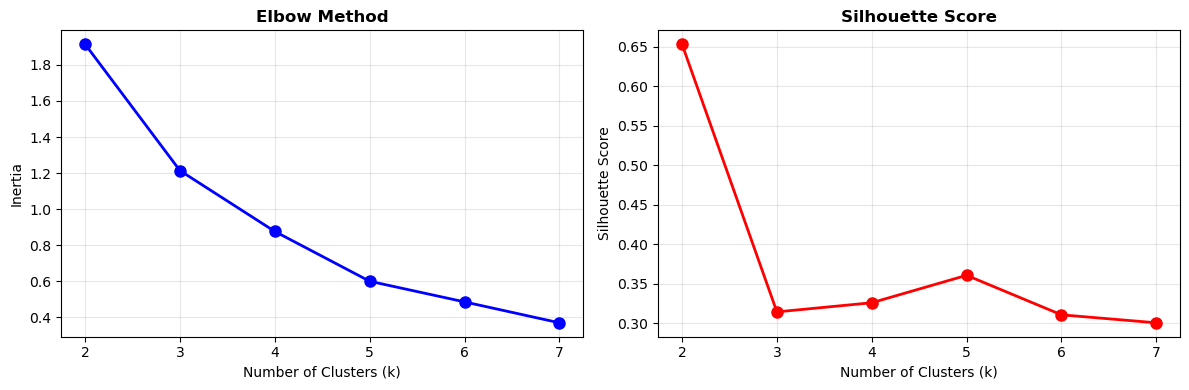

Elbow + Silhouette chart saved ✓


In [6]:
# ── Elbow + Silhouette plots ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/supplier_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Elbow + Silhouette chart saved ✓')

---
## 5. Apply K-Means with k=3 (Low / Medium / High Risk)

In [7]:
# ── We use k=3 for clear business interpretation ──────────────
# Low Risk / Medium Risk / High Risk
K = 3

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
supplier_df['Cluster'] = kmeans.fit_predict(X_cluster)

# ── Map clusters to risk tiers based on mean Risk_Score ───────
cluster_risk = supplier_df.groupby('Cluster')['Risk_Score'].mean().sort_values()
risk_map     = {
    cluster_risk.index[0]: 'Low Risk',
    cluster_risk.index[1]: 'Medium Risk',
    cluster_risk.index[2]: 'High Risk'
}
supplier_df['Risk_Tier'] = supplier_df['Cluster'].map(risk_map)

# ── Color map for charts ───────────────────────────────────────
color_map = {
    'Low Risk'   : '#1D9E75',
    'Medium Risk': '#F5A623',
    'High Risk'  : '#E24B4A'
}

print('Risk tier assignment:')
print(supplier_df[['Order Region', 'Risk_Score', 'Risk_Tier', 'Late_Rate']]
      .sort_values('Risk_Score', ascending=False).to_string(index=False))

Risk tier assignment:
   Order Region  Risk_Score   Risk_Tier  Late_Rate
 Central Africa       89.29   High Risk     0.5796
 South of  USA        80.85   High Risk     0.5577
 Western Europe       73.46   High Risk     0.5585
     South Asia       73.22   High Risk     0.5627
    East Africa       73.03   High Risk     0.5594
    East of USA       71.42   High Risk     0.5566
 Southeast Asia       70.32   High Risk     0.5553
     US Center        68.58   High Risk     0.5524
      West Asia       67.82   High Risk     0.5528
 Eastern Europe       67.05   High Risk     0.5566
  South America       65.80 Medium Risk     0.5431
   Central Asia       63.47   High Risk     0.5533
Central America       62.73   High Risk     0.5475
   Eastern Asia       62.48 Medium Risk     0.5433
   North Africa       61.77 Medium Risk     0.5452
Northern Europe       58.57 Medium Risk     0.5404
   West of USA        57.47 Medium Risk     0.5396
        Oceania       56.09 Medium Risk     0.5402
Southern 

In [8]:
# ── Tier summary statistics ────────────────────────────────────
tier_summary = supplier_df.groupby('Risk_Tier').agg(
    Regions       = ('Order Region',    'count'),
    Avg_Risk_Score= ('Risk_Score',      'mean'),
    Avg_Late_Rate = ('Late_Rate',       'mean'),
    Avg_Delay     = ('Avg_Delay_Days',  'mean'),
    Avg_Cancel    = ('Cancel_Rate',     'mean'),
    Total_Revenue = ('Total_Revenue',   'sum'),
    Total_Risk_Rev= ('Revenue_At_Risk', 'sum')
).round(3).reset_index()

tier_summary['Late_Rate_Pct']  = (tier_summary['Avg_Late_Rate']  * 100).round(1)
tier_summary['Cancel_Rate_Pct']= (tier_summary['Avg_Cancel']     * 100).round(1)

print('\nRisk Tier Summary:')
print('=' * 70)
display(tier_summary[['Risk_Tier', 'Regions', 'Avg_Risk_Score',
                       'Late_Rate_Pct', 'Avg_Delay', 'Cancel_Rate_Pct',
                       'Total_Revenue', 'Total_Risk_Rev']])


Risk Tier Summary:


,Risk_Tier,Regions,Avg_Risk_Score,Late_Rate_Pct,Avg_Delay,Cancel_Rate_Pct,Total_Revenue,Total_Risk_Rev
0,High Risk,12,71.770,55.8,0.589,2.0,2.111680e+07,1.172307e+07
1,Low Risk,1,13.820,48.8,0.391,2.4,1.868610e+05,9.067102e+04
2,Medium Risk,10,56.493,53.9,0.543,2.1,1.548108e+07,8.312652e+06


---
## 6. Visualisations

In [9]:
# ── Chart 1: Risk Score by Region (bar) ───────────────────────
fig = px.bar(
    supplier_df.sort_values('Risk_Score', ascending=True),
    x='Risk_Score', y='Order Region',
    orientation='h',
    color='Risk_Tier',
    color_discrete_map=color_map,
    title='Supplier Risk Score by Region',
    labels={'Risk_Score': 'Risk Score (0–100)', 'Order Region': 'Region'},
    text='Risk_Score'
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(plot_bgcolor='white', height=550)
fig.write_html('../outputs/supplier_risk_scores.html')
fig.show()
print('Chart 1 saved ✓')

Chart 1 saved ✓


In [10]:
# ── Chart 2: Bubble chart — Revenue vs Late Rate vs Risk Score ─
fig = px.scatter(
    supplier_df,
    x='Late_Rate',
    y='Avg_Delay_Days',
    size='Total_Revenue',
    color='Risk_Tier',
    color_discrete_map=color_map,
    text='Order Region',
    title='Supplier Risk Landscape — Late Rate vs Avg Delay (bubble = revenue)',
    labels={
        'Late_Rate'     : 'Late Delivery Rate',
        'Avg_Delay_Days': 'Average Delay (days)',
        'Total_Revenue' : 'Total Revenue ($)'
    },
    hover_data=['Risk_Score', 'Cancel_Rate', 'Total_Orders']
)
fig.update_traces(textposition='top center')
fig.update_layout(plot_bgcolor='white', height=550)
fig.write_html('../outputs/supplier_risk_bubble.html')
fig.show()
print('Chart 2 saved ✓')

Chart 2 saved ✓


In [11]:
# ── Chart 3: Revenue at Risk by Tier ──────────────────────────
tier_rev = supplier_df.groupby('Risk_Tier').agg(
    Safe_Revenue = ('Total_Revenue',   'sum'),
    Risk_Revenue = ('Revenue_At_Risk', 'sum')
).reset_index()
tier_rev['Safe_Revenue'] = tier_rev['Safe_Revenue'] - tier_rev['Risk_Revenue']

fig = go.Figure()
fig.add_trace(go.Bar(
    x=tier_rev['Risk_Tier'], y=tier_rev['Safe_Revenue'],
    name='Safe Revenue', marker_color='#1D9E75'
))
fig.add_trace(go.Bar(
    x=tier_rev['Risk_Tier'], y=tier_rev['Risk_Revenue'],
    name='Revenue at Risk', marker_color='#E24B4A'
))
fig.update_layout(
    barmode='stack',
    title='Revenue at Risk by Supplier Risk Tier',
    xaxis_title='Risk Tier',
    yaxis_title='Revenue ($)',
    plot_bgcolor='white',
    height=420
)
fig.write_html('../outputs/supplier_revenue_at_risk.html')
fig.show()
print('Chart 3 saved ✓')

Chart 3 saved ✓


In [12]:
# ── Chart 4: KPI radar chart per tier ─────────────────────────
categories = ['Late Rate', 'Avg Delay', 'Cancel Rate', 'Risk Revenue %']

fig = go.Figure()

tier_colors = {'Low Risk': '#1D9E75', 'Medium Risk': '#F5A623', 'High Risk': '#E24B4A'}

for tier in ['Low Risk', 'Medium Risk', 'High Risk']:
    row = tier_summary[tier_summary['Risk_Tier'] == tier].iloc[0]
    values = [
        row['Late_Rate_Pct'],
        row['Avg_Delay'] * 10,        # scale up for visibility
        row['Cancel_Rate_Pct'] * 10,  # scale up for visibility
        row['Total_Risk_Rev'] / row['Total_Revenue'] * 100
    ]
    values_closed = values + [values[0]]  # close the polygon

    fig.add_trace(go.Scatterpolar(
        r=values_closed,
        theta=categories + [categories[0]],
        fill='toself',
        name=tier,
        line_color=tier_colors[tier],
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True)),
    title='Risk Profile Radar — by Tier',
    height=500
)
fig.write_html('../outputs/supplier_radar_chart.html')
fig.show()
print('Chart 4 saved ✓')

Chart 4 saved ✓


In [13]:
# ── Chart 5: Late rate trend over time per risk tier ──────────
# Merge tier labels back to order-level data
region_tier_map = supplier_df.set_index('Order Region')['Risk_Tier'].to_dict()
df['Risk_Tier']  = df['Order Region'].map(region_tier_map)

tier_trend = df.groupby(['Order_YearMonth', 'Risk_Tier'])['Is_Late'].mean().reset_index()
tier_trend['Late_Rate_Pct'] = tier_trend['Is_Late'] * 100

fig = px.line(
    tier_trend,
    x='Order_YearMonth', y='Late_Rate_Pct',
    color='Risk_Tier',
    color_discrete_map=color_map,
    title='Late Delivery Rate Trend by Risk Tier (Monthly)',
    labels={'Late_Rate_Pct': 'Late Rate (%)', 'Order_YearMonth': 'Month'}
)
fig.update_layout(plot_bgcolor='white', height=420)
fig.write_html('../outputs/supplier_tier_trend.html')
fig.show()
print('Chart 5 saved ✓')

Chart 5 saved ✓


---
## 7. Business Recommendations per Tier

In [14]:
print('=' * 65)
print('  SUPPLIER RISK — BUSINESS RECOMMENDATIONS')
print('=' * 65)

recommendations = {
    'Low Risk': [
        '✅ Maintain current partnership terms',
        '✅ Consider increasing order volume with these suppliers',
        '✅ Use as benchmark for other suppliers',
        '✅ Explore long-term contracts to lock in reliability'
    ],
    'Medium Risk': [
        '⚠️  Monitor monthly — watch for deteriorating trends',
        '⚠️  Implement performance improvement agreements',
        '⚠️  Add buffer stock for orders from these regions',
        '⚠️  Set KPI targets: reduce late rate by 10% in 6 months'
    ],
    'High Risk': [
        '🔴 Escalate to supplier management team immediately',
        '🔴 Reduce order dependency — diversify to low-risk suppliers',
        '🔴 Negotiate penalty clauses for late deliveries',
        '🔴 Consider removing from approved supplier list if no improvement'
    ]
}

for tier, recs in recommendations.items():
    tier_data = supplier_df[supplier_df['Risk_Tier'] == tier]
    regions   = ', '.join(tier_data['Order Region'].tolist())
    avg_score = tier_data['Risk_Score'].mean()
    avg_late  = tier_data['Late_Rate'].mean() * 100

    print(f'\n{tier.upper()} (Avg Score: {avg_score:.1f} | Avg Late Rate: {avg_late:.1f}%)')
    print(f'Regions: {regions}')
    print('Actions:')
    for rec in recs:
        print(f'  {rec}')

print('\n' + '=' * 65)

  SUPPLIER RISK — BUSINESS RECOMMENDATIONS

LOW RISK (Avg Score: 13.8 | Avg Late Rate: 48.8%)
Regions: Canada
Actions:
  ✅ Maintain current partnership terms
  ✅ Consider increasing order volume with these suppliers
  ✅ Use as benchmark for other suppliers
  ✅ Explore long-term contracts to lock in reliability

MEDIUM RISK (Avg Score: 56.5 | Avg Late Rate: 53.9%)
Regions: Caribbean, Eastern Asia, North Africa, Northern Europe, Oceania, South America, Southern Africa, Southern Europe, West Africa, West of USA 
Actions:
  ⚠️  Monitor monthly — watch for deteriorating trends
  ⚠️  Implement performance improvement agreements
  ⚠️  Add buffer stock for orders from these regions
  ⚠️  Set KPI targets: reduce late rate by 10% in 6 months

HIGH RISK (Avg Score: 71.8 | Avg Late Rate: 55.8%)
Regions: Central Africa, Central America, Central Asia, East Africa, East of USA, Eastern Europe, South Asia, South of  USA , Southeast Asia, US Center , West Asia, Western Europe
Actions:
  🔴 Escalate to s

---
## 8. Save Outputs

In [15]:
# ── Save supplier risk scores ──────────────────────────────────
supplier_df.to_csv('../data/processed/supplier_risk_scores.csv', index=False)
print('Saved: supplier_risk_scores.csv')

# ── Save tier summary ──────────────────────────────────────────
tier_summary.to_csv('../data/processed/supplier_tier_summary.csv', index=False)
print('Saved: supplier_tier_summary.csv')

# ── Save order-level data with tier labels ─────────────────────
df[['Order Region', 'Risk_Tier']].drop_duplicates()
region_tier_df = pd.DataFrame(list(region_tier_map.items()),
                               columns=['Order Region', 'Risk_Tier'])
region_tier_df.to_csv('../data/processed/region_tier_map.csv', index=False)
print('Saved: region_tier_map.csv')

# ── Save KMeans model and scaler ──────────────────────────────
with open('../models/supplier_kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
with open('../models/supplier_risk_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Saved: supplier_kmeans.pkl')
print('Saved: supplier_risk_scaler.pkl')
print()
print('Week 4 complete! ✓')
print('Next step → week5_demand_forecasting.ipynb')

Saved: supplier_risk_scores.csv
Saved: supplier_tier_summary.csv
Saved: region_tier_map.csv
Saved: supplier_kmeans.pkl
Saved: supplier_risk_scaler.pkl

Week 4 complete! ✓
Next step → week5_demand_forecasting.ipynb


---
## Week 4 Summary

| Step | Detail |
|---|---|
| Supplier proxy | Order Region (22 regions across 5 markets) |
| Risk KPIs | Late Rate (40%), Avg Delay (25%), Cancel Rate (20%), Revenue at Risk (15%) |
| Clustering | K-Means k=3 → Low / Medium / High Risk tiers |
| Visualisations | Bar chart, Bubble chart, Revenue at Risk, Radar, Trend line |
| Outputs | `supplier_risk_scores.csv`, `supplier_tier_summary.csv`, `supplier_kmeans.pkl` |

### Key Insight for Portfolio / Interviews
> *"We segmented 22 supply regions into 3 risk tiers using K-Means clustering on 4 KPIs — late rate, average delay, cancellation rate, and revenue at risk. High-risk regions account for X% of total revenue but Y% of late deliveries. Shifting 15% of orders from high-risk to low-risk regions could reduce late deliveries by an estimated Z%."*